## Exploratory Data Analysis

This section includes an analysis of the distribution and statistical properties of the dataset variables. The goal of this analysis is to examine patient characteristics, analyze vital signs and laboratory variables, and prepare the data for machine learning models used to predict sepsis.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
# Dataset 
df = pd.read_csv("C:/Users/karol/Praca Magisterska Gworek/plik.csv")
df.head()

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_ID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,1
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,1
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,1
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,1
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,1


Data exploration and descriptive statistics

In [3]:
# Number of unique patients
num_patients = df['patient_ID'].nunique()
print(f'Total number of unique patients: {num_patients}')

Total number of unique patients: 40315


In [4]:
# Initial data overview
print("Variables:")
print(df.info())

print("\nFirst rows of the dataset:")
print(df.head())

print("\nDescriptive statistics:")
print(df.describe())

Variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1551446 entries, 0 to 1551445
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   HR                1398097 non-null  float64
 1   O2Sat             1348794 non-null  float64
 2   Temp              524935 non-null   float64
 3   SBP               1325245 non-null  float64
 4   MAP               1358242 non-null  float64
 5   DBP               1065099 non-null  float64
 6   Resp              1313190 non-null  float64
 7   EtCO2             57633 non-null    float64
 8   BaseExcess        84118 non-null    float64
 9   HCO3              64993 non-null    float64
 10  FiO2              129315 non-null   float64
 11  pH                107526 non-null   float64
 12  PaCO2             86265 non-null    float64
 13  SaO2              53540 non-null    float64
 14  AST               25178 non-null    float64
 15  BUN               106513 non-null   fl

### Vital signs analysis

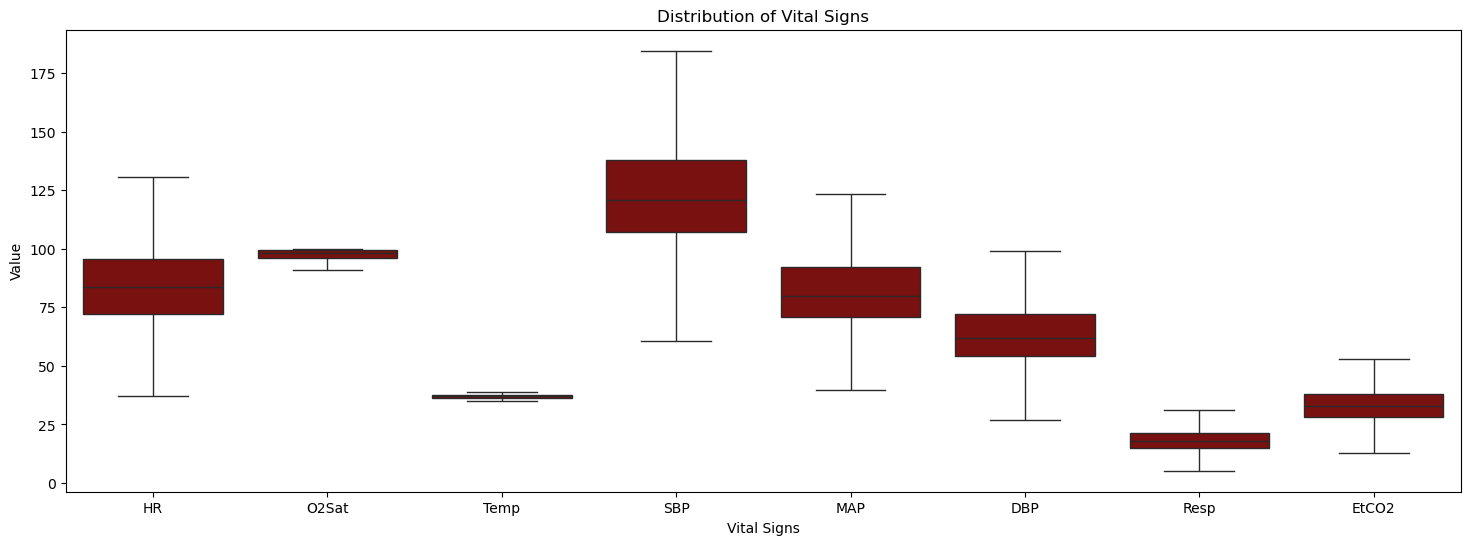

In [5]:
# Columns containing vital signs
vital_signs = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

# Reshape data for visualization
df_plot = df[vital_signs].melt(var_name='Vital Signs', value_name='Value')

# Boxplot of vital signs
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_plot, x='Vital Signs', y='Value', showfliers=False, color='darkred')

plt.xlabel("Vital Signs")
plt.ylabel("Value")
plt.title("Distribution of Vital Signs")
plt.show()

### Statistical summary of vital signs

In [6]:
# Mean, min, max, median
stats_vital = df[vital_signs].describe().T[['mean', 'min', 'max', '50%']]
stats_vital.rename(columns={'50%': 'median'}, inplace=True)

# Quartiles
stats_vital['Q1'] = df[vital_signs].quantile(0.25)
stats_vital['Q3'] = df[vital_signs].quantile(0.75)

# Standard deviation and kurtosis
stats_vital['std'] = df[vital_signs].std()
stats_vital['kurtosis'] = df[vital_signs].kurt()

print(stats_vital)

             mean   min    max  median     Q1     Q3        std   kurtosis
HR      84.580808  20.0  280.0    83.5   72.0   95.5  17.326385   0.400265
O2Sat   97.194197  20.0  100.0    98.0   96.0   99.5   2.936491  59.016769
Temp    36.977235  20.9   50.0    37.0   36.5   37.5   0.770009   4.050378
SBP    123.749231  20.0  300.0   121.0  107.0  138.0  23.229942   0.437204
MAP     82.399914  20.0  300.0    80.0   71.0   92.0  16.340318   5.054882
DBP     63.830238  20.0  300.0    62.0   54.0   72.0  13.955397   5.454628
Resp    18.726051   1.0  100.0    18.0   15.0   21.5   5.098284   4.355649
EtCO2   32.957542  10.0  100.0    33.0   28.0   38.0   7.951852   4.962218


### Outlier detection using IQR

In [7]:
def count_outliers_iqr(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return len(outliers)


# Count outliers for each vital sign variable
outlier_counts = {col: count_outliers_iqr(df[col]) for col in vital_signs}

# Convert to DataFrame
outlier_counts_df = pd.DataFrame(list(outlier_counts.items()),
                                 columns=["Variable", "Number of Outliers"])

# Percentage of outliers
outlier_counts_df["Outlier Percentage"] = (
    outlier_counts_df["Number of Outliers"] / len(df) * 100
)

# Sort by number of outliers
outlier_counts_df.sort_values(by="Number of Outliers", ascending=False, inplace=True)

print(outlier_counts_df)

  Variable  Number of Outliers  Outlier Percentage
6     Resp               27846            1.794842
1    O2Sat               24763            1.596124
4      MAP               21880            1.410297
5      DBP               16286            1.049730
3      SBP               15835            1.020661
0       HR               14031            0.904382
2     Temp                6568            0.423347
7    EtCO2                 938            0.060460


### Laboratory parameters analysis

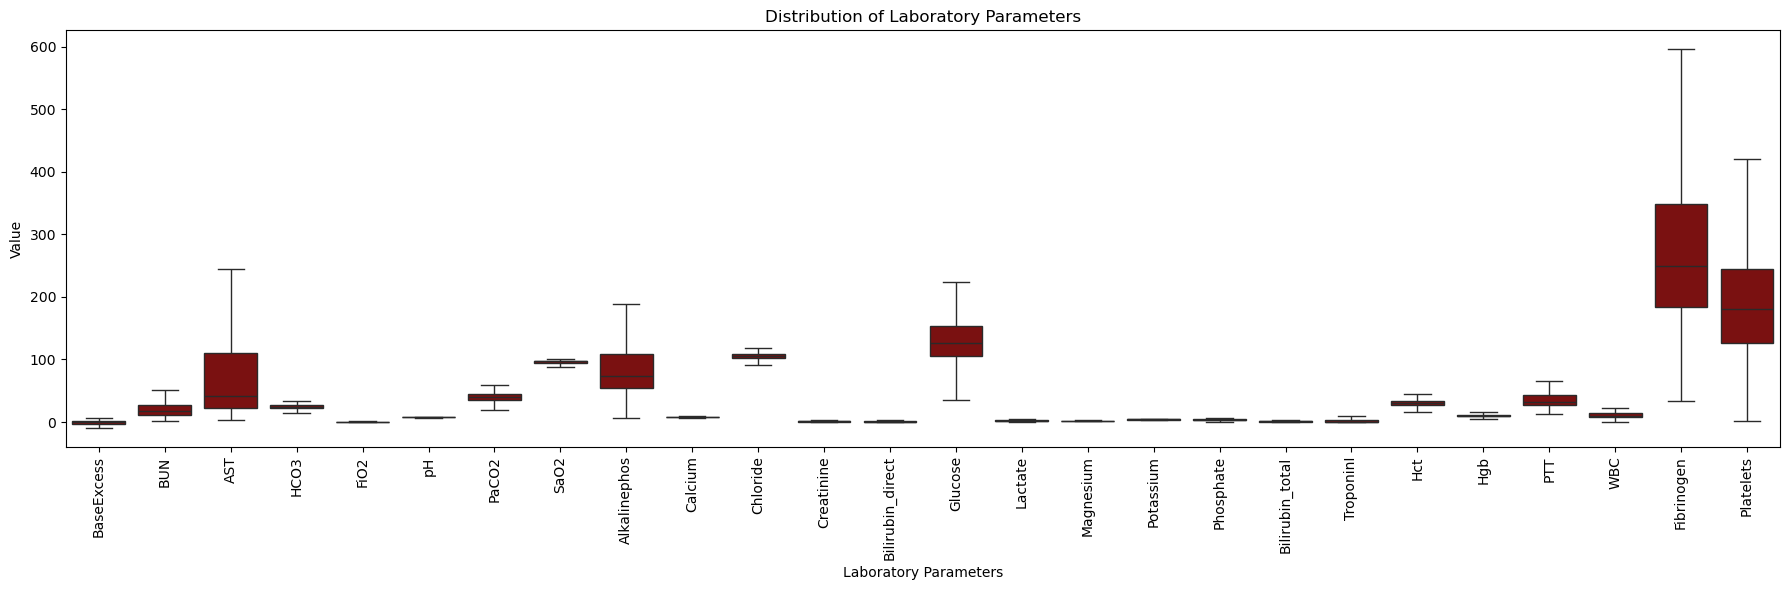

In [8]:
# Laboratory variables
lab_parameters = [
    'BaseExcess','BUN','AST','HCO3','FiO2','pH','PaCO2','SaO2','Alkalinephos',
    'Calcium','Chloride','Creatinine','Bilirubin_direct','Glucose','Lactate',
    'Magnesium','Potassium','Phosphate','Bilirubin_total','TroponinI','Hct',
    'Hgb','PTT','WBC','Fibrinogen','Platelets'
]

# Reshape data for visualization
df_plot = df[lab_parameters].melt(var_name='Laboratory Parameters', value_name='Value')

# Boxplot
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_plot, x='Laboratory Parameters', y='Value',
            showfliers=False, color='darkred')

plt.xticks(rotation=90)
plt.xlabel("Laboratory Parameters")
plt.ylabel("Value")
plt.title("Distribution of Laboratory Parameters")

plt.tight_layout()
plt.show()

### Descriptive statistics for laboratory variables

In [9]:
stats_lab = df[lab_parameters].describe().T[['mean', 'min', 'max', '50%']]
stats_lab.rename(columns={'50%': 'median'}, inplace=True)

stats_lab['Q1'] = df[lab_parameters].quantile(0.25)
stats_lab['Q3'] = df[lab_parameters].quantile(0.75)

stats_lab['std'] = df[lab_parameters].std()
stats_lab['kurtosis'] = df[lab_parameters].kurt()

print(stats_lab)

                        mean    min      max  median      Q1      Q3  \
BaseExcess         -0.689879 -32.00   100.00    0.00   -3.00    1.00   
BUN                23.912705   1.00   268.00   17.00   12.00   28.00   
AST               260.260128   3.00  9961.00   41.00   22.00  111.00   
HCO3               24.076137   0.00    55.00   24.00   22.00   26.90   
FiO2                0.554833 -50.00  4000.00    0.50    0.40    0.60   
pH                  7.378928   6.62     7.93    7.38    7.34    7.43   
PaCO2              41.023190  10.00   100.00   40.00   35.00   45.00   
SaO2               92.653959  23.00   100.00   97.00   94.00   98.00   
Alkalinephos      102.489293   7.00  3833.00   74.00   54.00  108.00   
Calcium             7.557908   1.00    27.90    8.30    7.70    8.70   
Chloride          105.828752  26.00   145.00  106.00  102.00  109.00   
Creatinine          1.510163   0.10    46.60    0.94    0.70    1.43   
Bilirubin_direct    1.836691   0.01    37.50    0.45    0.20    

### Density plots of laboratory variables

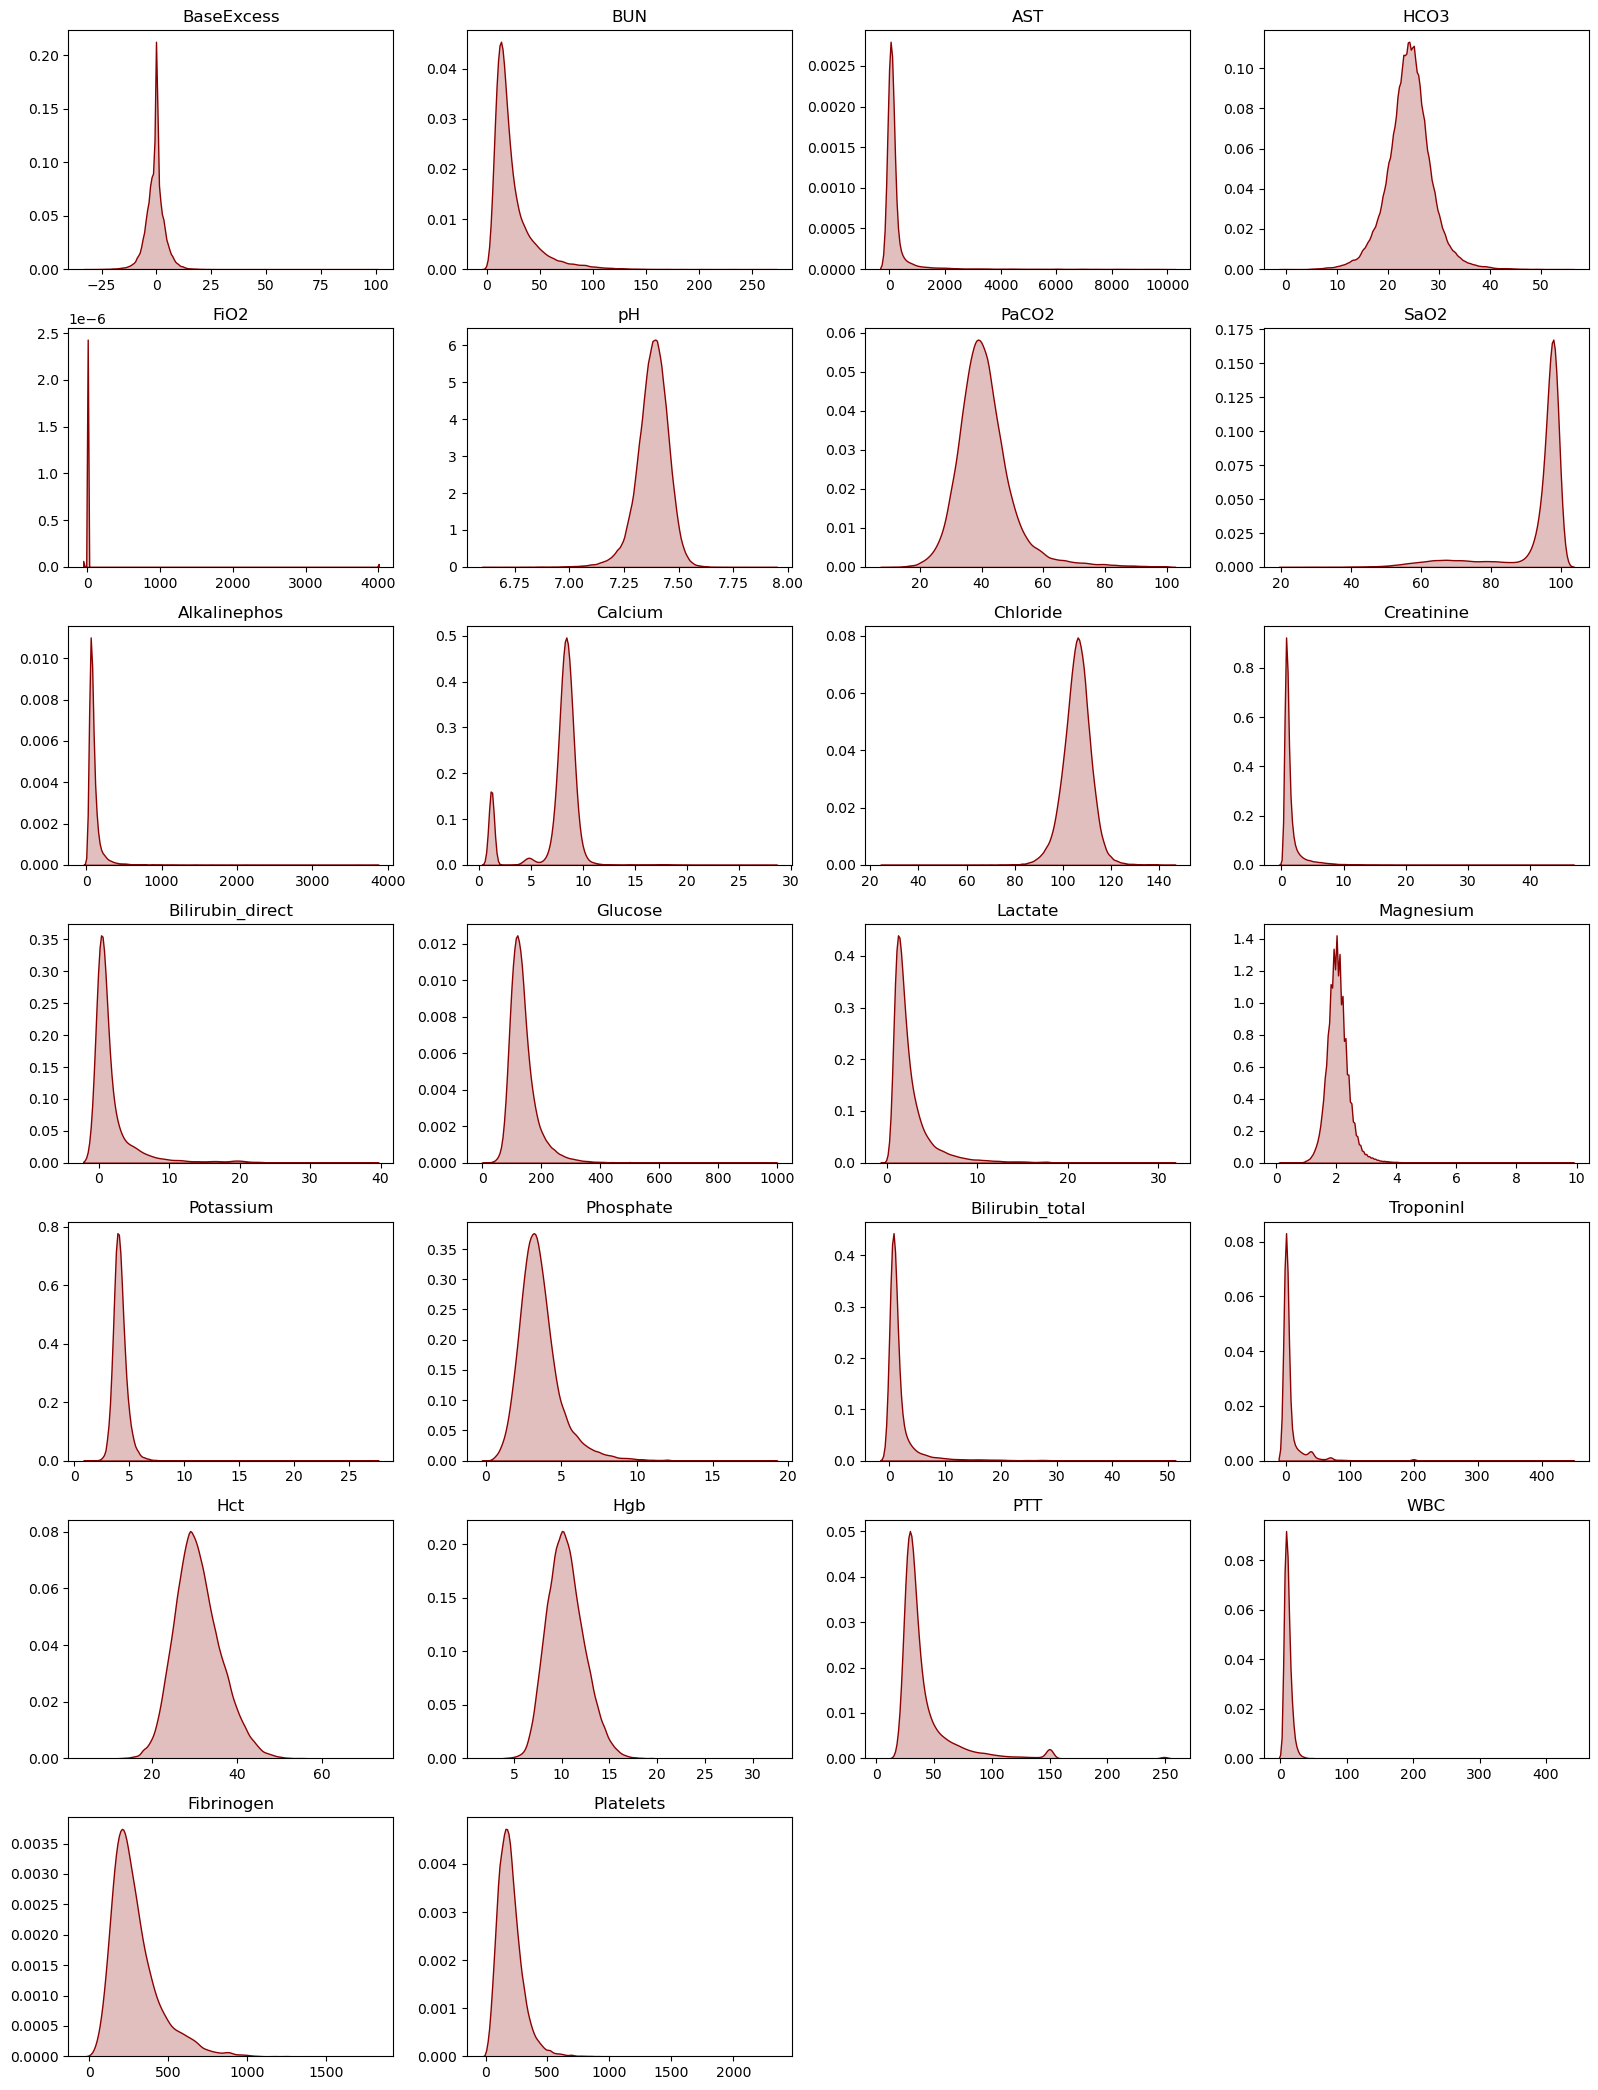

In [10]:
num_cols = 4
num_rows = (len(lab_parameters) + num_cols - 1) // num_cols

plt.figure(figsize=(4 * num_cols, 3 * num_rows))

for i, col in enumerate(lab_parameters, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.kdeplot(df[col].dropna(), fill=True, color='darkred')
    plt.title(col)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Gender distribution

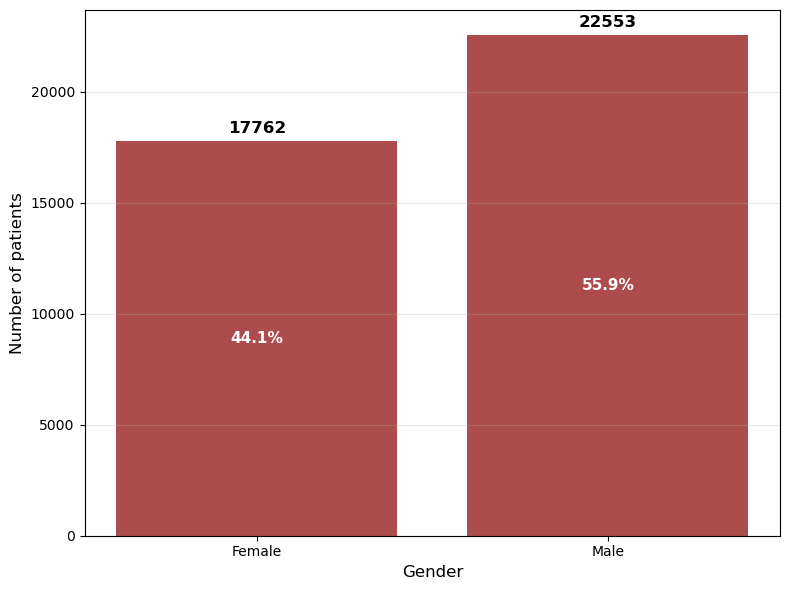

In [11]:
# Bar chart for gender distribution

plt.figure(figsize=(8, 6))

# Unique patients
df_unique = df.drop_duplicates(subset=['patient_ID'])

# Counts for each gender
gender_counts = df_unique['Gender'].value_counts().sort_index()

# Bar plot
bars = plt.bar(['Female', 'Male'], gender_counts.values,
               color=['darkred', 'darkred'], alpha=0.7, linewidth=1)

plt.ylabel('Number of patients', fontsize=12)
plt.xlabel('Gender', fontsize=12)

# Add counts above bars
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + max(gender_counts.values)*0.01, str(v),
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Add percentages inside bars
total = sum(gender_counts.values)
for i, v in enumerate(gender_counts.values):
    percentage = (v / total) * 100
    plt.text(i, v/2, f'{percentage:.1f}%',
             ha='center', va='center', fontweight='bold', fontsize=11, color='white')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Age distribution

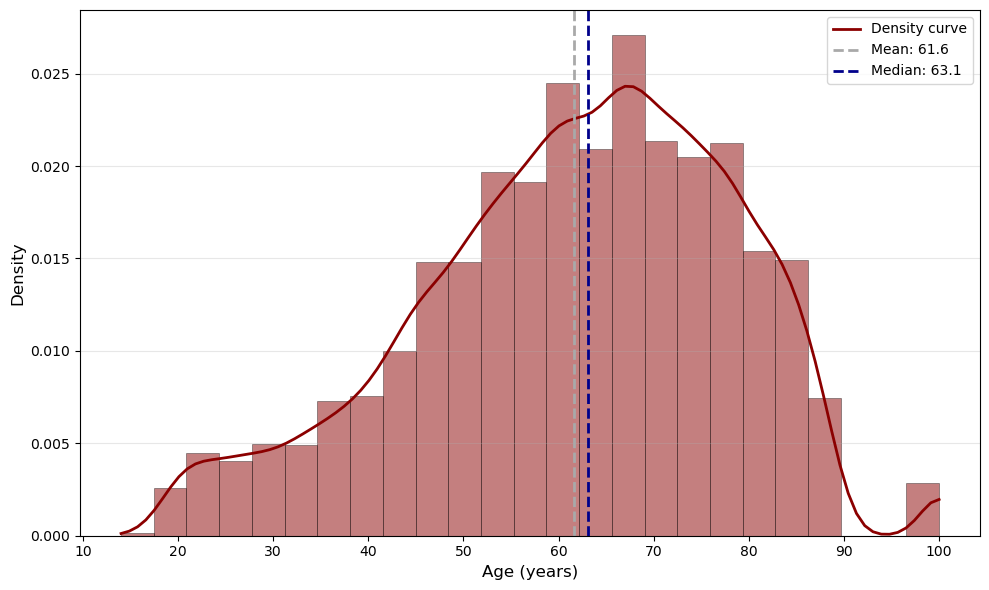

In [12]:
from scipy.stats import gaussian_kde

# Age data
age_data = df_unique['Age'].dropna()

# Basic statistics
age_stats = age_data.describe()

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(age_data, bins=25, density=True, alpha=0.5,
        color='#8B0000', edgecolor='black', linewidth=0.5)

# Density curve
x = np.linspace(age_data.min(), age_data.max(), 100)
kde = gaussian_kde(age_data)
ax.plot(x, kde(x), color='darkred', linewidth=2, label='Density curve')

# Axis ticks every 10 years
min_age = int(age_data.min()) // 10 * 10
max_age = int(age_data.max()) // 10 * 10
ax.set_xticks(np.arange(min_age, max_age + 1, 10))

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Mean and median lines
ax.axvline(age_stats['mean'], color='darkgray', linestyle='--',
           linewidth=2, label=f'Mean: {age_stats["mean"]:.1f}')
ax.axvline(age_stats['50%'], color='darkblue', linestyle='--',
           linewidth=2, label=f'Median: {age_stats["50%"]:.1f}')

ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Time variables distribution

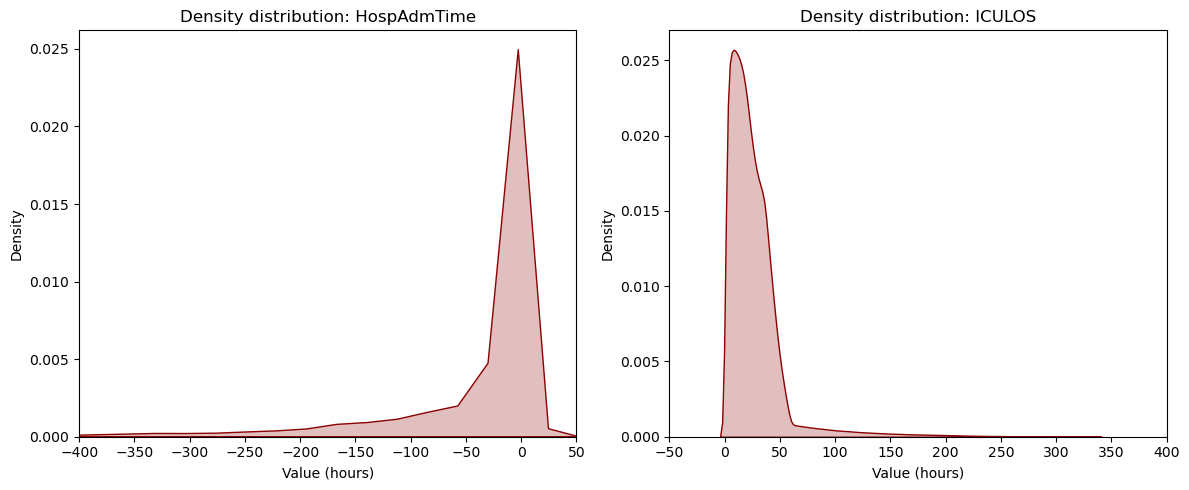

In [13]:
# Time variables
time_variables = ['HospAdmTime', 'ICULOS']

# X-axis ranges
x_ranges = {
    'HospAdmTime': (-400, 50),
    'ICULOS': (-50, 400)
}

plt.figure(figsize=(12, 5))

for i, var in enumerate(time_variables, 1):
    plt.subplot(1, 2, i)

    sns.kdeplot(df[var].dropna(), fill=True, color='darkred', bw_adjust=1)

    plt.title(f'Density distribution: {var}')
    plt.xlabel('Value (hours)')
    plt.ylabel('Density')

    if var in x_ranges:
        plt.xlim(x_ranges[var])

plt.tight_layout()
plt.show()

### Descriptive statistics for demographic and time variables

In [14]:
# Demographic and time variables
demographic_vars = ['Age', 'HospAdmTime', 'ICULOS']

# Statistical summary
stats_demo = df[demographic_vars].describe().T[['mean', 'min', 'max', '50%']]
stats_demo.rename(columns={'50%': 'median'}, inplace=True)

# Quartiles
stats_demo['Q1'] = df[demographic_vars].quantile(0.25)
stats_demo['Q3'] = df[demographic_vars].quantile(0.75)

# Standard deviation
stats_demo['std'] = df[demographic_vars].std()

# Kurtosis
stats_demo['kurtosis'] = df[demographic_vars].kurt()

print(stats_demo)

                  mean      min     max  median     Q1     Q3         std  \
Age          62.008685    14.00  100.00   64.00  51.68  74.00   16.387082   
HospAdmTime -56.133152 -5366.86   23.99   -6.03 -47.07  -0.04  162.271418   
ICULOS       26.995949     1.00  336.00   21.00  11.00  34.00   29.009386   

               kurtosis  
Age           -0.191077  
HospAdmTime  277.791934  
ICULOS        24.637507  


### ICU unit distribution

In [15]:
# Unique patients
df_unique = df.drop_duplicates(subset='patient_ID')

# Patients only in Unit1
unit1 = df_unique[(df_unique['Unit1'] == 1) & (df_unique['Unit2'] == 0)].shape[0]

# Patients only in Unit2
unit2 = df_unique[(df_unique['Unit1'] == 0) & (df_unique['Unit2'] == 1)].shape[0]

# Patients in both units
both_units = df_unique[(df_unique['Unit1'] == 1) & (df_unique['Unit2'] == 1)].shape[0]

# Patients in neither unit
neither = df_unique[(df_unique['Unit1'] == 0) & (df_unique['Unit2'] == 0)].shape[0]

print(f'Only Unit1: {unit1}')
print(f'Only Unit2: {unit2}')
print(f'Both units: {both_units}')
print(f'Neither unit: {neither}')

Only Unit1: 12257
Only Unit2: 12448
Both units: 0
Neither unit: 0


### ICU unit visualization

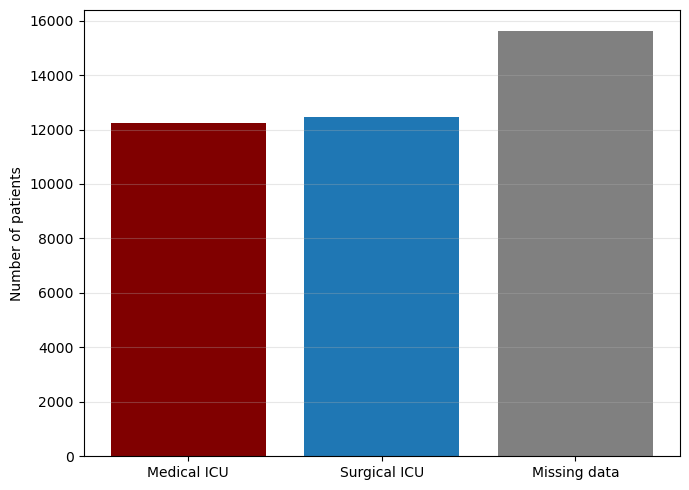

In [16]:
# Missing unit information
missing_units = df_unique[
    df_unique['Unit1'].isna() & df_unique['Unit2'].isna()
].shape[0]

labels = ['Medical ICU', 'Surgical ICU', 'Missing data']
values = [unit1, unit2, missing_units]

plt.figure(figsize=(7, 5))
plt.bar(labels, values, color=['maroon', '#1f77b4', 'gray'])

plt.ylabel('Number of patients')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()